# VideoMamba Tiny — IPN Hand Continuous Recognition + CUDA-native Post-processing (Kaggle)

Bản này test **một continuous video**, dùng `window=64`, `step=32` (overlap đúng 50%), sample `T=16`, build CUDA-native `causal_conv1d_cuda` + `selective_scan_cuda`, rồi chạy smoothing → linking → removing → Frame-wise Accuracy / temporal overlap.

## 0. Chuẩn bị Kaggle runtime

Bật **GPU** và **Internet** trong Kaggle Settings trước khi chạy.

In [2]:
# Các package này thường đã có trên Kaggle; pip chỉ bổ sung nếu thiếu.
%pip install -q timm einops transformers opencv-python-headless matplotlib pandas numpy torchvision tqdm scikit-learn

import os
import sys
import subprocess
from pathlib import Path

VIDEOMAMBA_REPO = Path("/kaggle/working/VideoMamba")
MAMBA_ROOT = VIDEOMAMBA_REPO / "mamba"
MAMBA_PACKAGE_DIR = MAMBA_ROOT / "mamba_ssm"
VIDEOMAMBA_PATH = VIDEOMAMBA_REPO / "videomamba" / "video_sm"

if not VIDEOMAMBA_REPO.exists():
    print("Cloning OpenGVLab/VideoMamba...")
    try:
        subprocess.run(
            ["git", "clone", "https://github.com/OpenGVLab/VideoMamba.git", str(VIDEOMAMBA_REPO)],
            check=True,
        )
    except Exception as e:
        raise RuntimeError(
            "Không clone được VideoMamba. Hãy bật Internet trong Kaggle Settings rồi chạy lại cell."
        ) from e
else:
    print(f"VideoMamba đã tồn tại: {VIDEOMAMBA_REPO}")

assert MAMBA_ROOT.is_dir(), f"Không tồn tại: {MAMBA_ROOT}"
assert MAMBA_PACKAGE_DIR.is_dir(), f"Không tồn tại package: {MAMBA_PACKAGE_DIR}"
assert (MAMBA_PACKAGE_DIR / "__init__.py").is_file(), "Thiếu mamba_ssm/__init__.py"
assert VIDEOMAMBA_PATH.is_dir(), f"Không tồn tại: {VIDEOMAMBA_PATH}"

# Parent directories của các package phải nằm trong sys.path.
for p in [str(VIDEOMAMBA_PATH), str(MAMBA_ROOT)]:
    while p in sys.path:
        sys.path.remove(p)
    sys.path.insert(0, p)

print("MAMBA_ROOT      :", MAMBA_ROOT)
print("VIDEOMAMBA_PATH:", VIDEOMAMBA_PATH)
print("mamba_ssm dir   :", MAMBA_PACKAGE_DIR)
print("sys.path[:3]    :", sys.path[:3])

Note: you may need to restart the kernel to use updated packages.
Cloning OpenGVLab/VideoMamba...


Cloning into '/kaggle/working/VideoMamba'...


MAMBA_ROOT      : /kaggle/working/VideoMamba/mamba
VIDEOMAMBA_PATH: /kaggle/working/VideoMamba/videomamba/video_sm
mamba_ssm dir   : /kaggle/working/VideoMamba/mamba/mamba_ssm
sys.path[:3]    : ['/kaggle/working/VideoMamba/mamba', '/kaggle/working/VideoMamba/videomamba/video_sm', '/kaggle/working']


## 1. Import VideoMamba + Mamba PyTorch fallback

Cell này giữ runtime đã chạy thành công trên Tesla T4 của Kaggle.  
`selective_scan_ref` ưu tiên độ ổn định để kiểm tra checkpoint/accuracy; không dùng số latency từ runtime này làm benchmark CUDA-native.

In [3]:
import os
import sys
import types
import random
import importlib
import importlib.machinery

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F

from einops import rearrange, repeat
from torchvision import transforms

# -------------------------------------------------------------------------
# 1) Dọn trạng thái import cũ để cell có thể chạy lại an toàn.
# -------------------------------------------------------------------------
for name in list(sys.modules):
    if name == "mamba_ssm" or name.startswith("mamba_ssm."):
        del sys.modules[name]

for name in ["causal_conv1d", "causal_conv1d_cuda", "selective_scan_cuda"]:
    sys.modules.pop(name, None)

importlib.invalidate_caches()

# -------------------------------------------------------------------------
# 2) Tạo package namespace mamba_ssm trỏ trực tiếp vào source repository.
#    Điều này xử lý trường hợp Kaggle thấy thư mục nhưng find_spec() trả None.
# -------------------------------------------------------------------------
mamba_pkg = types.ModuleType("mamba_ssm")
mamba_pkg.__file__ = str(MAMBA_PACKAGE_DIR / "__init__.py")
mamba_pkg.__path__ = [str(MAMBA_PACKAGE_DIR)]
mamba_pkg.__package__ = "mamba_ssm"

mamba_spec = importlib.machinery.ModuleSpec(
    name="mamba_ssm",
    loader=None,
    is_package=True,
)
mamba_spec.submodule_search_locations = [str(MAMBA_PACKAGE_DIR)]
mamba_pkg.__spec__ = mamba_spec
sys.modules["mamba_ssm"] = mamba_pkg

# -------------------------------------------------------------------------
# 3) PyTorch fallback cho causal_conv1d.
# -------------------------------------------------------------------------
causal_mod = types.ModuleType("causal_conv1d")

def causal_conv1d_fn(x, weight, bias=None, activation=None):
    seqlen = x.shape[-1]
    dim = x.shape[1]
    width = weight.shape[-1]

    # Source Mamba thường truyền weight dạng (D, W).
    # Một số call site có thể truyền (D, 1, W).
    if weight.ndim == 2:
        w = weight.unsqueeze(1)
    elif weight.ndim == 3:
        w = weight
    else:
        raise ValueError(f"causal_conv1d weight shape không hợp lệ: {tuple(weight.shape)}")

    out = F.conv1d(
        x,
        w,
        bias=bias,
        padding=width - 1,
        groups=dim,
    )[..., :seqlen]

    if activation in ["silu", "swish"]:
        out = F.silu(out)
    return out

def causal_conv1d_update(*args, **kwargs):
    raise NotImplementedError(
        "causal_conv1d_update không được dùng trong VideoMamba inference batch này."
    )

causal_mod.causal_conv1d_fn = causal_conv1d_fn
causal_mod.causal_conv1d_update = causal_conv1d_update

sys.modules["causal_conv1d"] = causal_mod
sys.modules["causal_conv1d_cuda"] = types.ModuleType("causal_conv1d_cuda")
sys.modules["selective_scan_cuda"] = types.ModuleType("selective_scan_cuda")

# -------------------------------------------------------------------------
# 4) PyTorch fallback cho RMSNorm/Triton layernorm.
# -------------------------------------------------------------------------
class RMSNorm(nn.Module):
    def __init__(self, d_model, eps=1e-5, device=None, dtype=None):
        super().__init__()
        self.eps = eps
        self.weight = nn.Parameter(
            torch.ones(d_model, device=device, dtype=dtype)
        )
        self.register_parameter("bias", None)

    def forward(self, x):
        return (
            x
            * torch.rsqrt(x.pow(2).mean(-1, keepdim=True) + self.eps)
            * self.weight
        )

def rms_norm_fn(
    x,
    weight,
    bias=None,
    residual=None,
    eps=1e-5,
    prenorm=False,
    residual_in_fp32=False,
):
    if residual is not None:
        if residual_in_fp32:
            residual = residual.float()
        x = x + residual
        res = x
    else:
        res = x

    normed = x * torch.rsqrt(
        x.pow(2).mean(-1, keepdim=True) + eps
    ) * weight

    if bias is not None:
        normed = normed + bias

    if prenorm:
        return normed, res
    return normed

triton_ln = types.ModuleType("mamba_ssm.ops.triton.layernorm")
triton_ln.RMSNorm = RMSNorm
triton_ln.layer_norm_fn = None
triton_ln.rms_norm_fn = rms_norm_fn
sys.modules["mamba_ssm.ops.triton.layernorm"] = triton_ln

# -------------------------------------------------------------------------
# 5) Compatibility shim cho một số phiên bản transformers.
# -------------------------------------------------------------------------
try:
    import transformers.generation
    if not hasattr(transformers.generation, "GreedySearchDecoderOnlyOutput"):
        transformers.generation.GreedySearchDecoderOnlyOutput = object
        transformers.generation.SampleDecoderOnlyOutput = object
except Exception:
    pass

# -------------------------------------------------------------------------
# 6) Import selective scan và Mamba từ source repository.
# -------------------------------------------------------------------------
import mamba_ssm.ops.selective_scan_interface as ssi
import mamba_ssm.modules.mamba_simple as ms

def mamba_inner_fn_no_out_proj(
    xz,
    conv1d_weight,
    conv1d_bias,
    x_proj_weight,
    delta_proj_weight,
    A,
    B=None,
    C=None,
    D=None,
    delta_bias=None,
    B_proj_bias=None,
    C_proj_bias=None,
    delta_softplus=True,
):
    L = xz.shape[-1]
    delta_rank = delta_proj_weight.shape[1]
    d_state = A.shape[-1] * (1 if not A.is_complex() else 2)

    x, z = xz.chunk(2, dim=1)

    x = causal_conv1d_fn(
        x,
        rearrange(conv1d_weight, "d 1 w -> d w"),
        conv1d_bias,
        "silu",
    )

    x_dbl = F.linear(
        rearrange(x, "b d l -> (b l) d"),
        x_proj_weight,
    )

    delta = delta_proj_weight @ x_dbl[:, :delta_rank].t()
    delta = rearrange(delta, "d (b l) -> b d l", l=L)

    if B is None:
        B = x_dbl[:, delta_rank : delta_rank + d_state]
        if B_proj_bias is not None:
            B = B + B_proj_bias.to(dtype=B.dtype)

        if not A.is_complex():
            B = rearrange(
                B, "(b l) dstate -> b dstate l", l=L
            ).contiguous()
        else:
            B = rearrange(
                B,
                "(b l) (dstate two) -> b dstate (l two)",
                l=L,
                two=2,
            ).contiguous()

    if C is None:
        C = x_dbl[:, -d_state:]
        if C_proj_bias is not None:
            C = C + C_proj_bias.to(dtype=C.dtype)

        if not A.is_complex():
            C = rearrange(
                C, "(b l) dstate -> b dstate l", l=L
            ).contiguous()
        else:
            C = rearrange(
                C,
                "(b l) (dstate two) -> b dstate (l two)",
                l=L,
                two=2,
            ).contiguous()

    return ssi.selective_scan_ref(
        x,
        delta,
        A,
        B,
        C,
        D,
        z=z,
        delta_bias=delta_bias,
        delta_softplus=delta_softplus,
    )

# Ép toàn bộ các call site chính dùng implementation PyTorch reference.
ssi.selective_scan_fn = ssi.selective_scan_ref
ssi.mamba_inner_fn = ssi.mamba_inner_ref
ssi.bimamba_inner_fn = ssi.bimamba_inner_ref
ssi.mamba_inner_fn_no_out_proj = mamba_inner_fn_no_out_proj

ms.selective_scan_fn = ssi.selective_scan_ref
ms.mamba_inner_fn = ssi.mamba_inner_ref
ms.bimamba_inner_fn = ssi.bimamba_inner_ref
ms.mamba_inner_fn_no_out_proj = mamba_inner_fn_no_out_proj

# VideoMamba model
from models import videomamba_tiny

print("OpenCV Version :", cv2.__version__)
print("PyTorch Version:", torch.__version__)
print("CUDA Available :", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU            :", torch.cuda.get_device_name(0))

print("mamba_ssm source:", MAMBA_PACKAGE_DIR)
print("VideoMamba import: OK")

/kaggle/working/VideoMamba/mamba/mamba_ssm/ops/selective_scan_interface.py:158: FutureWarning: `torch.cuda.amp.custom_fwd(args...)` is deprecated. Please use `torch.amp.custom_fwd(args..., device_type='cuda')` instead.
  @custom_fwd
/kaggle/working/VideoMamba/mamba/mamba_ssm/ops/selective_scan_interface.py:227: FutureWarning: `torch.cuda.amp.custom_bwd(args...)` is deprecated. Please use `torch.amp.custom_bwd(args..., device_type='cuda')` instead.
  @custom_bwd
/kaggle/working/VideoMamba/mamba/mamba_ssm/ops/selective_scan_interface.py:295: FutureWarning: `torch.cuda.amp.custom_fwd(args...)` is deprecated. Please use `torch.amp.custom_fwd(args..., device_type='cuda')` instead.
  @custom_fwd
/kaggle/working/VideoMamba/mamba/mamba_ssm/ops/selective_scan_interface.py:368: FutureWarning: `torch.cuda.amp.custom_bwd(args...)` is deprecated. Please use `torch.amp.custom_bwd(args..., device_type='cuda')` instead.
  @custom_bwd
/kaggle/working/VideoMamba/mamba/mamba_ssm/ops/selective_scan_interf

OpenCV Version : 4.13.0
PyTorch Version: 2.10.0+cu128
CUDA Available : True
GPU            : Tesla T4
mamba_ssm source: /kaggle/working/VideoMamba/mamba/mamba_ssm
VideoMamba import: OK


## 2. Cấu hình IPN Hand gốc và checkpoint

In [4]:
from pathlib import Path
import os
import re

# ---------------------------------------------------------------------
# Kaggle paths — đúng với dataset/checkpoint hiện tại
# ---------------------------------------------------------------------
DATASET_ROOT = Path(
    "/kaggle/input/datasets/soumicksarker/ipn-hand-dataset"
)

ANNOT_DIR = DATASET_ROOT / "annotations" / "annotations"
DATASET_VIDEOS_DIR = DATASET_ROOT / "videos" / "videos"

ANNOT_ALL_PATH = ANNOT_DIR / "Annot_List.txt"
ANNOT_TRAIN_PATH = ANNOT_DIR / "Annot_TrainList.txt"
ANNOT_TEST_PATH = ANNOT_DIR / "Annot_TestList.txt"

VIDEO_TRAIN_LIST_PATH = ANNOT_DIR / "Video_TrainList.txt"
VIDEO_TEST_LIST_PATH = ANNOT_DIR / "Video_TestList.txt"
CLASS_IDX_PATH = ANNOT_DIR / "classIdx.txt"

CHECKPOINT_PATH = Path(
    "/kaggle/input/models/hoanganh94/"
    "bestcheckpoint/pytorch/default/1/checkpoint-best.pth"
)

# ---------------------------------------------------------------------
# Model configuration — PHẢI khớp checkpoint train
# ---------------------------------------------------------------------
NUM_FRAMES = 16
IMG_SIZE = 224
NUM_CLASSES = 14

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Official 14-class ordering of IPN Hand (dataset IDs 1..14).
CLASS_CODES = [
    "D0X", "B0A", "B0B",
    "G01", "G02", "G03", "G04", "G05", "G06",
    "G07", "G08", "G09", "G10", "G11",
]

CLASS_DESCRIPTIONS = [
    "No gesture",
    "Pointing with one finger",
    "Pointing with two fingers",
    "Click with one finger",
    "Click with two fingers",
    "Throw up",
    "Throw down",
    "Throw left",
    "Throw right",
    "Open twice",
    "Double click with one finger",
    "Double click with two fingers",
    "Zoom in",
    "Zoom out",
]

CLASS_NAMES = [
    f"{code} - {desc}"
    for code, desc in zip(CLASS_CODES, CLASS_DESCRIPTIONS)
]

# ---------------------------------------------------------------------
# Fail-fast path validation
# ---------------------------------------------------------------------
required_paths = {
    "dataset root": DATASET_ROOT,
    "video dir": DATASET_VIDEOS_DIR,
    "Annot_List": ANNOT_ALL_PATH,
    "Annot_TrainList": ANNOT_TRAIN_PATH,
    "Annot_TestList": ANNOT_TEST_PATH,
    "checkpoint": CHECKPOINT_PATH,
}

for name, p in required_paths.items():
    print(f"{name:18s}: {p} -> {p.exists()}")

assert DATASET_VIDEOS_DIR.is_dir(), f"Không tìm thấy video dir: {DATASET_VIDEOS_DIR}"
assert ANNOT_TEST_PATH.is_file(), f"Không tìm thấy: {ANNOT_TEST_PATH}"
assert CHECKPOINT_PATH.is_file(), f"Không tìm thấy checkpoint: {CHECKPOINT_PATH}"

video_files = sorted(DATASET_VIDEOS_DIR.glob("*.avi"))
print(f"\nSố video .avi: {len(video_files)}")
print("DEVICE:", DEVICE)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

dataset root      : /kaggle/input/datasets/soumicksarker/ipn-hand-dataset -> True
video dir         : /kaggle/input/datasets/soumicksarker/ipn-hand-dataset/videos/videos -> True
Annot_List        : /kaggle/input/datasets/soumicksarker/ipn-hand-dataset/annotations/annotations/Annot_List.txt -> True
Annot_TrainList   : /kaggle/input/datasets/soumicksarker/ipn-hand-dataset/annotations/annotations/Annot_TrainList.txt -> True
Annot_TestList    : /kaggle/input/datasets/soumicksarker/ipn-hand-dataset/annotations/annotations/Annot_TestList.txt -> True
checkpoint        : /kaggle/input/models/hoanganh94/bestcheckpoint/pytorch/default/1/checkpoint-best.pth -> True

Số video .avi: 200
DEVICE: cuda
GPU: Tesla T4


## 3. Đọc annotation gốc và map tên video Kaggle

Code benchmark IPN Hand đọc `Annot_*List.txt` bằng dấu phẩy và sử dụng:

- cột 0: video
- cột 2: class ID (1–14)
- cột 3: start frame
- cột 4: end frame

Dataset Kaggle có một số filename dạng `...R__197.avi`; annotation gốc có thể dùng ký tự phân cách khác. Hàm canonicalization bên dưới bỏ ký tự đặc biệt để map hai tên về cùng một video.

In [5]:
def canonical_video_key(name):
    """
    Chuẩn hóa tên video để:
      1CM1_1_R_#217
      1CM1_1_R__217.avi
    map về cùng một key.
    """
    name = Path(str(name).strip()).stem.lower()
    return re.sub(r"[^a-z0-9]", "", name)


# Index 200 video thực tế trên Kaggle.
VIDEO_INDEX = {
    canonical_video_key(p.name): p
    for p in DATASET_VIDEOS_DIR.glob("*.avi")
}

def resolve_video_path(video_name):
    key = canonical_video_key(video_name)
    return VIDEO_INDEX.get(key, None)


def read_ipn_annotations(path):
    """
    Đọc Annot_List / Annot_TrainList / Annot_TestList gốc.

    Format benchmark dùng tối thiểu 5 field comma-separated:
        video, label_text, class_id, start_frame, end_frame

    class_id trong file là 1..14.
    """
    raw = pd.read_csv(
        path,
        sep=",",
        header=None,
        dtype=str,
        engine="python",
    )

    if raw.shape[1] < 5:
        raise ValueError(
            f"{path.name} chỉ có {raw.shape[1]} cột; "
            "cần ít nhất 5 cột theo format IPN Hand."
        )

    df = raw.iloc[:, :5].copy()
    df.columns = ["video", "label", "id", "t_start", "t_end"]

    for col in ["video", "label"]:
        df[col] = df[col].astype(str).str.strip()

    for col in ["id", "t_start", "t_end"]:
        df[col] = pd.to_numeric(df[col], errors="coerce")

    # Nếu file có header ngoài dự kiến, dòng đó sẽ thành NaN và được bỏ.
    df = df.dropna(subset=["id", "t_start", "t_end"]).copy()

    df["id"] = df["id"].astype(int)
    df["t_start"] = df["t_start"].astype(int)
    df["t_end"] = df["t_end"].astype(int)

    # Chỉ giữ class ID hợp lệ.
    df = df[df["id"].between(1, NUM_CLASSES)].copy()

    # Resolve video file.
    df["video_path"] = df["video"].apply(resolve_video_path)
    df["video_found"] = df["video_path"].notna()

    # Model class index = dataset ID - 1.
    df["class_idx"] = df["id"] - 1
    df["class_code"] = df["class_idx"].map(
        lambda i: CLASS_CODES[i] if 0 <= i < NUM_CLASSES else "?"
    )

    return df.reset_index(drop=True)


df_all = read_ipn_annotations(ANNOT_ALL_PATH)
df_train = read_ipn_annotations(ANNOT_TRAIN_PATH)
df_test = read_ipn_annotations(ANNOT_TEST_PATH)

print("Annotation rows:")
print("  all  :", len(df_all))
print("  train:", len(df_train))
print("  test :", len(df_test))

print("\nVideo mapping:")
print(f"  all   matched: {df_all['video_found'].sum()}/{len(df_all)}")
print(f"  train matched: {df_train['video_found'].sum()}/{len(df_train)}")
print(f"  test  matched: {df_test['video_found'].sum()}/{len(df_test)}")

unmatched = df_all.loc[~df_all["video_found"], "video"].drop_duplicates()
if len(unmatched):
    print("\nVí dụ annotation chưa map được:")
    print(unmatched.head(10).tolist())

print("\nTest annotation preview:")
display(df_test.head(10))

Annotation rows:
  all  : 5649
  train: 4039
  test : 1610

Video mapping:
  all   matched: 5649/5649
  train matched: 4039/4039
  test  matched: 1610/1610

Test annotation preview:


,video,label,id,t_start,t_end,video_path,video_found,class_idx,class_code
0,1CM1_1_R__217,D0X,1,1,28,/kaggle/input/datasets/soumicksarker/ipn-hand-...,True,0,D0X
1,1CM1_1_R__217,G10,13,29,72,/kaggle/input/datasets/soumicksarker/ipn-hand-...,True,12,G10
2,1CM1_1_R__217,B0A,2,73,235,/kaggle/input/datasets/soumicksarker/ipn-hand-...,True,1,B0A
3,1CM1_1_R__217,G07,10,236,260,/kaggle/input/datasets/soumicksarker/ipn-hand-...,True,9,G07
4,1CM1_1_R__217,B0A,2,261,448,/kaggle/input/datasets/soumicksarker/ipn-hand-...,True,1,B0A
5,1CM1_1_R__217,G11,14,449,509,/kaggle/input/datasets/soumicksarker/ipn-hand-...,True,13,G11
6,1CM1_1_R__217,B0B,3,510,756,/kaggle/input/datasets/soumicksarker/ipn-hand-...,True,2,B0B
7,1CM1_1_R__217,G06,9,757,788,/kaggle/input/datasets/soumicksarker/ipn-hand-...,True,8,G06
8,1CM1_1_R__217,B0B,3,789,1064,/kaggle/input/datasets/soumicksarker/ipn-hand-...,True,2,B0B
9,1CM1_1_R__217,G04,7,1065,1101,/kaggle/input/datasets/soumicksarker/ipn-hand-...,True,6,G04


## 4. Khởi tạo VideoMamba Tiny và load checkpoint

In [6]:
def load_videomamba_model(
    checkpoint_path,
    num_classes=NUM_CLASSES,
    device=DEVICE,
):
    print("--> Khởi tạo VideoMamba Tiny")

    model = videomamba_tiny(
        img_size=IMG_SIZE,
        num_frames=NUM_FRAMES,
        kernel_size=1,
        num_classes=num_classes,
    )

    checkpoint = torch.load(
        checkpoint_path,
        map_location="cpu",
        weights_only=False,
    )

    state_dict = checkpoint.get("model", checkpoint)

    clean_state_dict = {}
    for k, v in state_dict.items():
        name = k[7:] if k.startswith("module.") else k
        clean_state_dict[name] = v

    try:
        model.load_state_dict(clean_state_dict, strict=True)
    except RuntimeError as e:
        print("\n[LOAD ERROR] Checkpoint không khớp architecture hiện tại.")
        print("Hãy kiểm tra đặc biệt NUM_FRAMES, NUM_CLASSES và model variant lúc train.")
        raise e

    model = model.to(device)
    model.eval()

    print("--> Load checkpoint thành công")
    print("    device    :", device)
    print("    num_frames:", NUM_FRAMES)
    print("    classes   :", NUM_CLASSES)

    return model


model = load_videomamba_model(CHECKPOINT_PATH)

--> Khởi tạo VideoMamba Tiny
Use checkpoint: False
Checkpoint number: 0
--> Load checkpoint thành công
    device    : cuda
    num_frames: 16
    classes   : 14


## 5. Tiền xử lý và lấy clip từ video liên tục

`t_start` và `t_end` của IPN Hand là frame index trong video gốc. Notebook lấy đúng đoạn annotation trước, sau đó sample `NUM_FRAMES` cho VideoMamba.

In [7]:
# ImageNet normalization — phải giữ giống pipeline train nếu checkpoint dùng preprocessing này.
transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize(IMG_SIZE),
    transforms.CenterCrop(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225],
    ),
])


def sample_indices(total_frames, num_frames=NUM_FRAMES, sampling_rate=2):
    """
    Nếu clip đủ dài: lấy num_frames với spacing=sampling_rate quanh tâm clip.
    Nếu clip ngắn: nội suy đều để luôn đủ num_frames.
    """
    if total_frames <= 0:
        return np.zeros(num_frames, dtype=np.int64)

    temporal_span = num_frames * sampling_rate

    if total_frames >= temporal_span:
        start = (total_frames - temporal_span) // 2
        return np.arange(
            start,
            start + temporal_span,
            sampling_rate,
            dtype=np.int64,
        )

    return np.linspace(
        0,
        total_frames - 1,
        num_frames,
    ).round().astype(np.int64)


def extract_frames_from_video(
    video_path,
    t_start=None,
    t_end=None,
    num_frames=NUM_FRAMES,
):
    cap = cv2.VideoCapture(str(video_path))

    if not cap.isOpened():
        raise ValueError(f"Không thể mở video: {video_path}")

    total_vid_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    # IPN annotation dùng frame index bắt đầu từ 1.
    start_f = max(1, int(t_start)) if t_start is not None else 1
    end_f = (
        min(total_vid_frames, int(t_end))
        if t_end is not None
        else total_vid_frames
    )

    if end_f < start_f:
        cap.release()
        raise ValueError(
            f"Frame range không hợp lệ: {start_f} -> {end_f}"
        )

    clip_len = end_f - start_f + 1

    sampled_rel_idx = sample_indices(
        clip_len,
        num_frames=num_frames,
    )
    sampled_abs_idx = start_f - 1 + sampled_rel_idx

    sampled_set = set(sampled_abs_idx.tolist())
    frames_dict = {}

    cap.set(cv2.CAP_PROP_POS_FRAMES, start_f - 1)
    curr_idx = start_f - 1

    while curr_idx <= end_f - 1 and len(frames_dict) < len(sampled_set):
        ret, frame = cap.read()
        if not ret:
            break

        if curr_idx in sampled_set:
            frames_dict[curr_idx] = cv2.cvtColor(
                frame,
                cv2.COLOR_BGR2RGB,
            )

        curr_idx += 1

    cap.release()

    frames = []
    last_valid = None

    for idx in sampled_abs_idx:
        idx = int(idx)

        if idx in frames_dict:
            f = frames_dict[idx]
            last_valid = f
        elif last_valid is not None:
            f = last_valid
        else:
            f = np.zeros(
                (IMG_SIZE, IMG_SIZE, 3),
                dtype=np.uint8,
            )

        frames.append(f)

    return np.asarray(frames), sampled_abs_idx + 1


def run_inference(model, frames_np, device=DEVICE):
    tensor = torch.stack(
        [transform(f) for f in frames_np]
    )

    # (T,C,H,W) -> (1,C,T,H,W)
    tensor = tensor.permute(1, 0, 2, 3).unsqueeze(0)
    tensor = tensor.to(device=device, dtype=torch.float32)

    with torch.no_grad():
        logits = model(tensor)
        probs = F.softmax(logits, dim=1).squeeze(0)

    probs = probs.detach().cpu().numpy()

    pred_idx = int(np.argmax(probs))
    confidence = float(probs[pred_idx])

    return pred_idx, confidence, probs

## 6. Test ngẫu nhiên các gesture segment từ **test split**

Không sample cả video dài. Mỗi mẫu được lấy từ một dòng `Annot_TestList.txt`.


MẪU #1
Video       : 1CM1_1_R__218.avi
Segment     : frame 240 -> 287
Ground truth: G10 - Zoom in [idx=12]
Prediction  : B0A - Pointing with one finger [idx=1]
Confidence  : 96.23%
Correct     : False


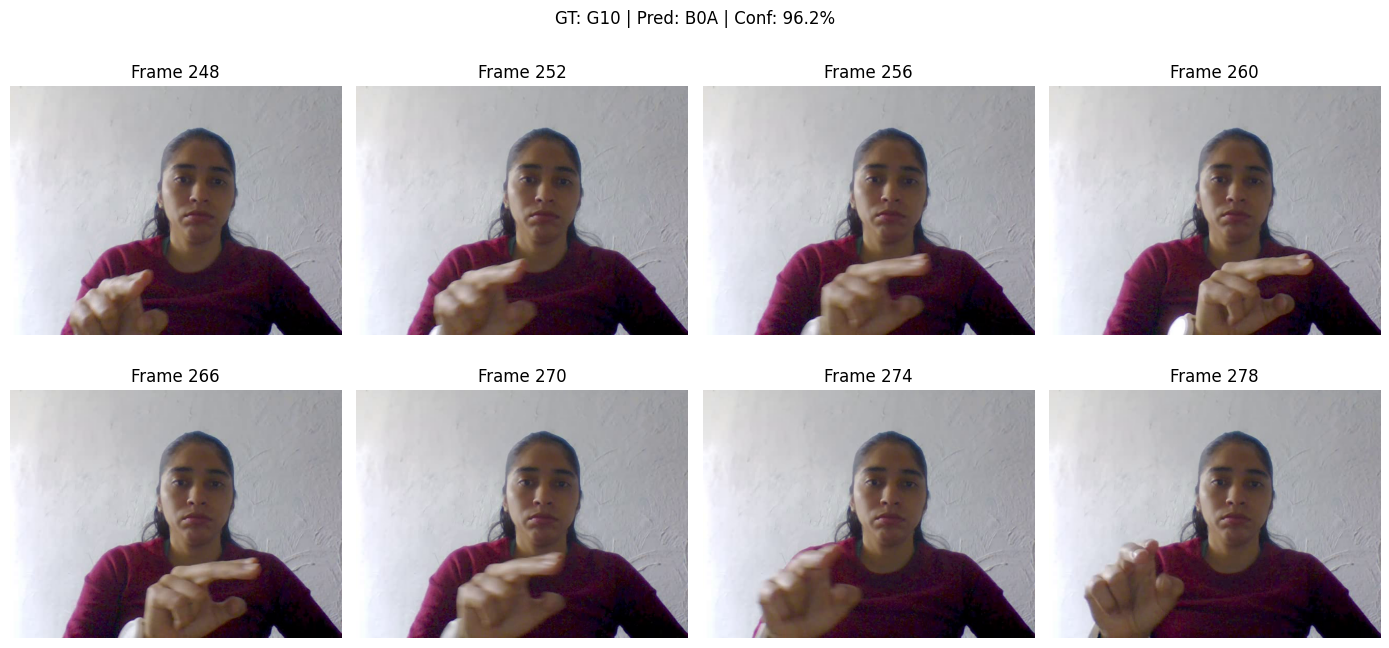

Top-3:
  1. B0A - Pointing with one finger = 96.23%
  2. B0B - Pointing with two fingers = 1.56%
  3. D0X - No gesture = 1.50%

MẪU #2
Video       : 1CM1_1_R__220.avi
Segment     : frame 3268 -> 3482
Ground truth: B0A - Pointing with one finger [idx=1]
Prediction  : B0A - Pointing with one finger [idx=1]
Confidence  : 96.62%
Correct     : True


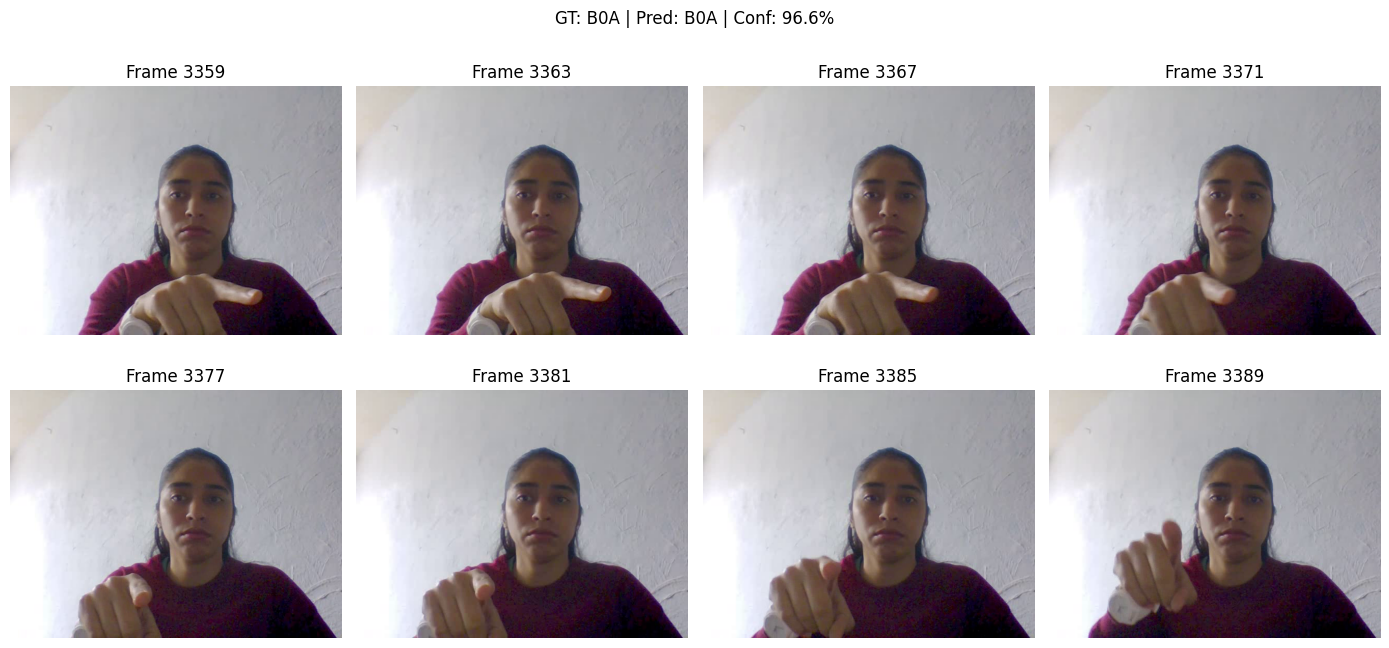

Top-3:
  1. B0A - Pointing with one finger = 96.62%
  2. D0X - No gesture = 1.36%
  3. G01 - Click with one finger = 0.94%

MẪU #3
Video       : 1CM42_31_R__132.avi
Segment     : frame 2840 -> 2941
Ground truth: G10 - Zoom in [idx=12]
Prediction  : G10 - Zoom in [idx=12]
Confidence  : 93.37%
Correct     : True


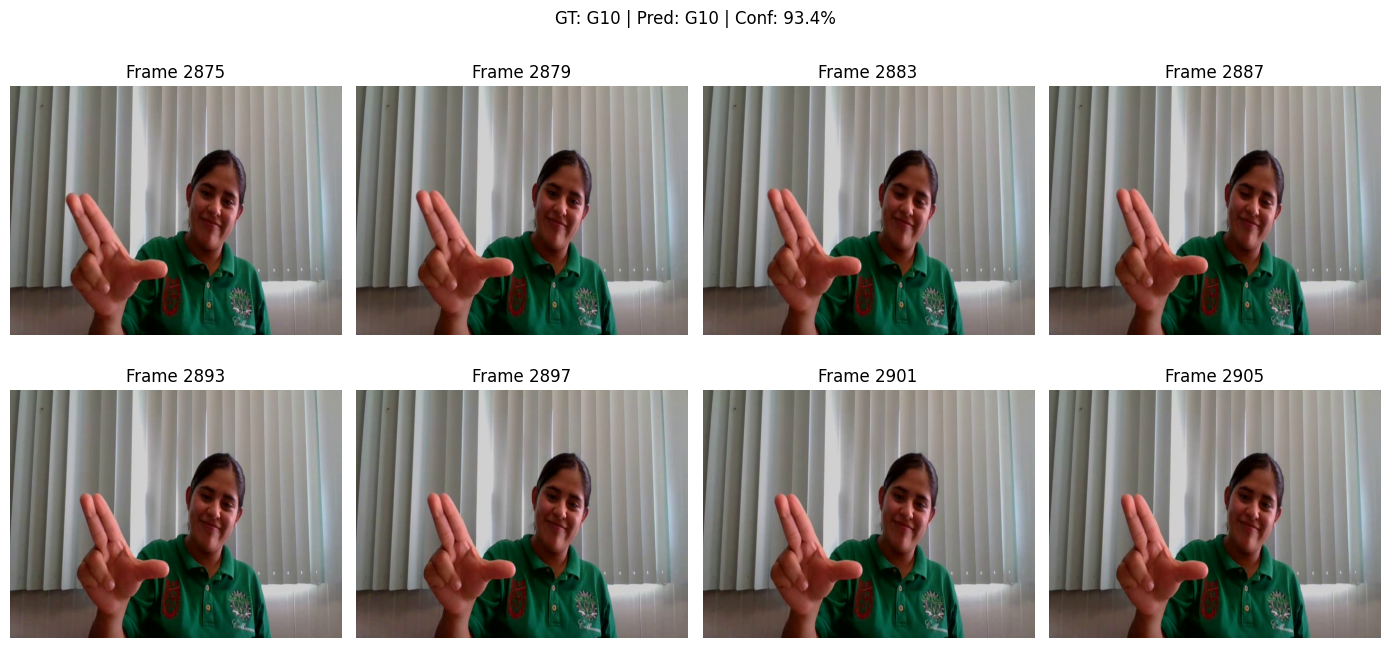

Top-3:
  1. G10 - Zoom in = 93.37%
  2. G11 - Zoom out = 5.85%
  3. G07 - Open twice = 0.28%


In [8]:
NUM_TEST_SAMPLES = 3

valid_test = df_test[df_test["video_found"]].copy()

assert len(valid_test) > 0, "Không có test annotation nào map được sang video."

sampled_df = valid_test.sample(
    n=min(NUM_TEST_SAMPLES, len(valid_test)),
    random_state=42,
)

for sample_no, (_, row) in enumerate(sampled_df.iterrows(), start=1):
    video_path = row["video_path"]
    t_start = int(row["t_start"])
    t_end = int(row["t_end"])
    true_idx = int(row["class_idx"])

    frames, sampled_frame_ids = extract_frames_from_video(
        video_path,
        t_start=t_start,
        t_end=t_end,
        num_frames=NUM_FRAMES,
    )

    pred_idx, conf, probs = run_inference(
        model,
        frames,
        device=DEVICE,
    )

    print("\n" + "=" * 80)
    print(f"MẪU #{sample_no}")
    print("Video       :", Path(video_path).name)
    print(f"Segment     : frame {t_start} -> {t_end}")
    print("Ground truth:", CLASS_NAMES[true_idx], f"[idx={true_idx}]")
    print("Prediction  :", CLASS_NAMES[pred_idx], f"[idx={pred_idx}]")
    print(f"Confidence  : {conf * 100:.2f}%")
    print("Correct     :", pred_idx == true_idx)
    print("=" * 80)

    # 8 frame đại diện.
    fig, axes = plt.subplots(2, 4, figsize=(14, 7))
    show_indices = np.linspace(
        0,
        len(frames) - 1,
        8,
    ).round().astype(int)

    for ax, fi in zip(axes.ravel(), show_indices):
        ax.imshow(frames[fi])
        ax.set_title(f"Frame {int(sampled_frame_ids[fi])}")
        ax.axis("off")

    plt.suptitle(
        f"GT: {CLASS_CODES[true_idx]} | "
        f"Pred: {CLASS_CODES[pred_idx]} | "
        f"Conf: {conf*100:.1f}%"
    )
    plt.tight_layout()
    plt.show()

    top3 = np.argsort(probs)[-3:][::-1]

    print("Top-3:")
    for rank, idx in enumerate(top3, start=1):
        print(
            f"  {rank}. {CLASS_NAMES[idx]} "
            f"= {probs[idx]*100:.2f}%"
        )

## 7. Test một segment tùy chọn

Có hai cách:

1. để `MANUAL_VIDEO = None` → notebook tự chọn một test annotation;
2. nhập tên video + `MANUAL_START`, `MANUAL_END`.

Tên video có thể dùng format annotation gốc hoặc filename Kaggle; hàm resolver sẽ canonicalize.

In [9]:
# Ví dụ:
# MANUAL_VIDEO = "1CM1_1_R_#217"
# MANUAL_START = 29
# MANUAL_END = 72

MANUAL_VIDEO = None
MANUAL_START = None
MANUAL_END = None

if MANUAL_VIDEO is None:
    row = valid_test.sample(n=1, random_state=7).iloc[0]
    custom_video_path = row["video_path"]
    custom_start = int(row["t_start"])
    custom_end = int(row["t_end"])
    custom_true_idx = int(row["class_idx"])
else:
    custom_video_path = resolve_video_path(MANUAL_VIDEO)

    if custom_video_path is None:
        raise FileNotFoundError(
            f"Không map được video: {MANUAL_VIDEO}"
        )

    if MANUAL_START is None or MANUAL_END is None:
        raise ValueError(
            "Khi MANUAL_VIDEO khác None, hãy nhập MANUAL_START và MANUAL_END."
        )

    custom_start = int(MANUAL_START)
    custom_end = int(MANUAL_END)
    custom_true_idx = None


frames, sampled_ids = extract_frames_from_video(
    custom_video_path,
    custom_start,
    custom_end,
    NUM_FRAMES,
)

pred_idx, conf, probs = run_inference(
    model,
    frames,
    DEVICE,
)

print("Video      :", Path(custom_video_path).name)
print("Segment    :", custom_start, "->", custom_end)

if custom_true_idx is not None:
    print("GT         :", CLASS_NAMES[custom_true_idx])

print("Prediction :", CLASS_NAMES[pred_idx])
print(f"Confidence : {conf*100:.2f}%")

Video      : 4CM11_18_R__48.avi
Segment    : 13 -> 65
GT         : G09 - Double click with two fingers
Prediction : G09 - Double click with two fingers
Confidence : 61.55%


## 8. One-video Continuous VideoMamba — prebuilt CUDA wheels, overlap 50%

- `WINDOW_SIZE = 64`
- `WINDOW_STEP = 32` → overlap = `50%`
- `MODEL_FRAMES = 16`
- test đúng **1 video**: `1CM1_2_R__224.avi`
- build native `causal_conv1d_cuda` và `selective_scan_cuda` từ source đi kèm VideoMamba
- giữ output `P_raw [N_windows, 14]` để post-processing.

CUDA extensions được cài lại từ Kaggle Input:

```text
/kaggle/input/datasets/hoanganh94/videomamba-t4-cuda-wheels
```

In [10]:
from pathlib import Path

WHEEL_DIR = Path(
    "/kaggle/input/datasets/hoanganh94/videomamba-t4-cuda-wheels"
)

CAUSAL_WHEEL = WHEEL_DIR / "causal_conv1d-1.0.0-cp312-cp312-linux_x86_64.whl"
MAMBA_WHEEL = WHEEL_DIR / "mamba_ssm-1.0.1-cp312-cp312-linux_x86_64.whl"

print("Wheel directory exists:", WHEEL_DIR.exists())
print("Causal wheel exists   :", CAUSAL_WHEEL.exists())
print("Mamba wheel exists    :", MAMBA_WHEEL.exists())

print("\nFiles in wheel directory:")
if WHEEL_DIR.exists():
    for p in WHEEL_DIR.iterdir():
        print(" -", p.name)

Wheel directory exists: True
Causal wheel exists   : True
Mamba wheel exists    : True

Files in wheel directory:
 - mamba_ssm-1.0.1-cp312-cp312-linux_x86_64.whl
 - causal_conv1d-1.0.0-cp312-cp312-linux_x86_64.whl


=== CUDA wheel environment ===
torch      : 2.10.0+cu128
torch CUDA : 12.8
GPU        : Tesla T4
wheel dir  : /kaggle/input/datasets/hoanganh94/videomamba-t4-cuda-wheels

Installing prebuilt CUDA wheels...


/kaggle/working/VideoMamba/mamba/mamba_ssm/ops/selective_scan_interface.py:158: FutureWarning: `torch.cuda.amp.custom_fwd(args...)` is deprecated. Please use `torch.amp.custom_fwd(args..., device_type='cuda')` instead.
  @custom_fwd
/kaggle/working/VideoMamba/mamba/mamba_ssm/ops/selective_scan_interface.py:227: FutureWarning: `torch.cuda.amp.custom_bwd(args...)` is deprecated. Please use `torch.amp.custom_bwd(args..., device_type='cuda')` instead.
  @custom_bwd
/kaggle/working/VideoMamba/mamba/mamba_ssm/ops/selective_scan_interface.py:295: FutureWarning: `torch.cuda.amp.custom_fwd(args...)` is deprecated. Please use `torch.amp.custom_fwd(args..., device_type='cuda')` instead.
  @custom_fwd
/kaggle/working/VideoMamba/mamba/mamba_ssm/ops/selective_scan_interface.py:368: FutureWarning: `torch.cuda.amp.custom_bwd(args...)` is deprecated. Please use `torch.amp.custom_bwd(args..., device_type='cuda')` instead.
  @custom_bwd
/kaggle/working/VideoMamba/mamba/mamba_ssm/ops/selective_scan_interf


=== Native CUDA extensions ===
causal_conv1d_cuda : /usr/local/lib/python3.12/dist-packages/causal_conv1d_cuda.cpython-312-x86_64-linux-gnu.so
selective_scan_cuda: /usr/local/lib/python3.12/dist-packages/selective_scan_cuda.cpython-312-x86_64-linux-gnu.so
mamba_ssm          : /kaggle/working/VideoMamba/mamba/mamba_ssm/__init__.py

selective_scan_fn : selective_scan_fn
selective_scan_ref: selective_scan_ref
CUDA-native selective scan: ACTIVE
--> Khởi tạo VideoMamba Tiny
Use checkpoint: False
Checkpoint number: 0
--> Load checkpoint thành công
    device    : cuda
    num_frames: 16
    classes   : 14
VideoMamba reloaded with native CUDA Mamba: OK

=== Continuous config ===
Video          : 1CM1_2_R__224.avi
Total frames   : 3843
FPS            : 30.0
Duration       : 128.10s
WINDOW_SIZE    : 64
WINDOW_STEP    : 32
OVERLAP        : 50.0%
MODEL_FRAMES   : 16
GT intervals   : 43
GT gestures    : 21
N_WINDOWS      : 120
Last padding   : 29

=== Native smoke test ===
window 0 pred   : G01 c

,Stage,Frame-wise Accuracy,Temporal Overlap Score,Gesture segments
0,Raw,0.772574,0.442585,20
1,After smoothing,0.749675,NaN,18
2,Final post-processing,0.749675,0.426996,18



Δ Frame Acc : -0.0229
Δ Overlap   : -0.0156


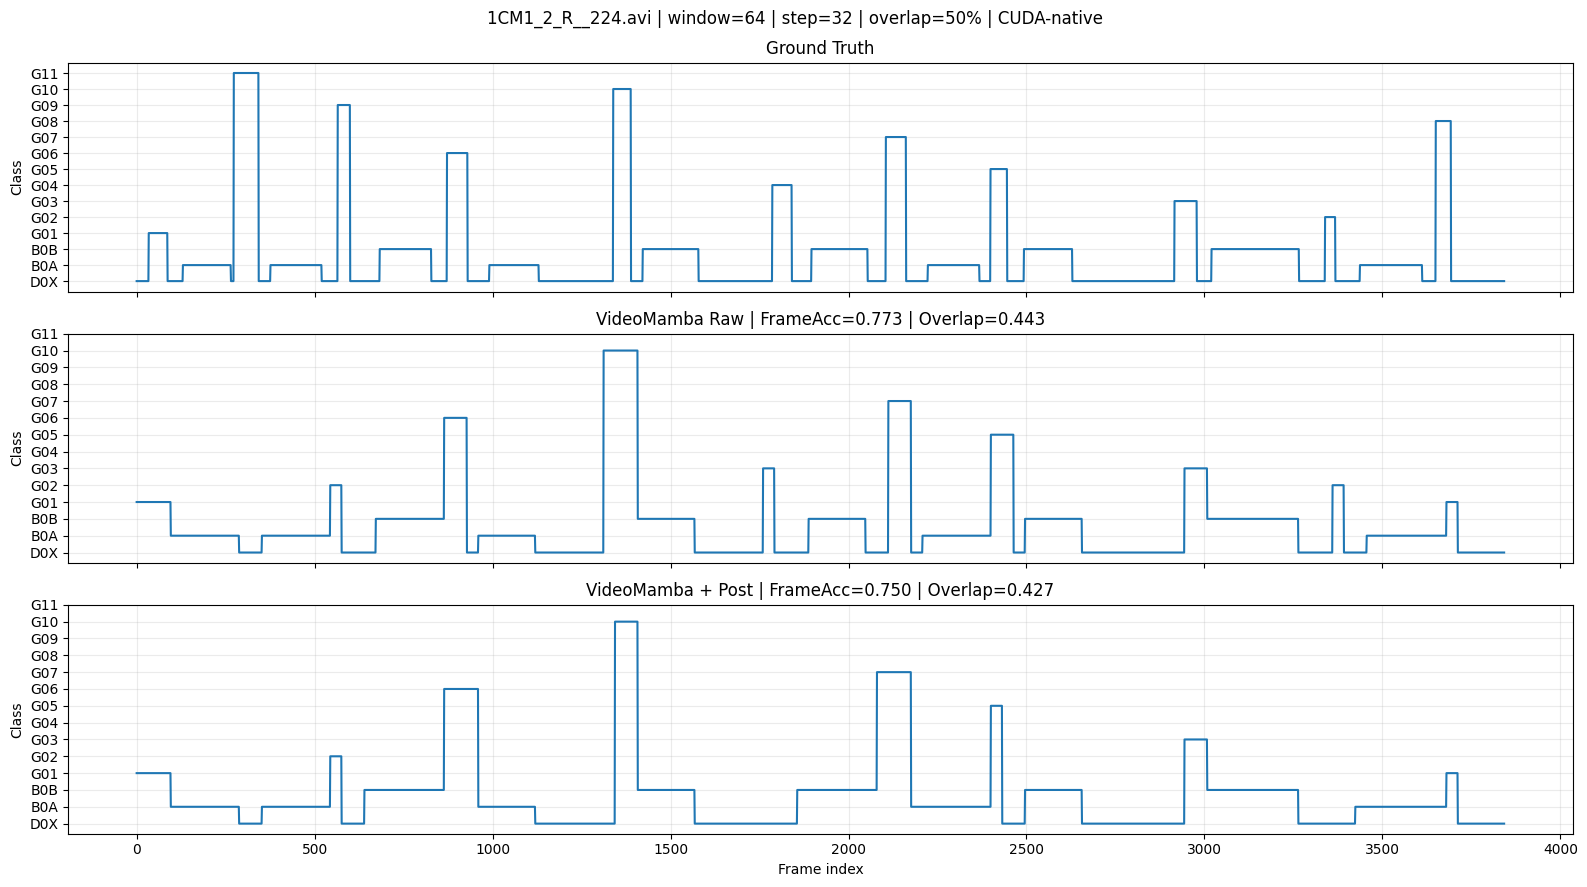


Kept variables:
P_raw          : (120, 14)
P_smooth       : (120, 14)
raw_segments   : 20
final_segments : 18
gt_segments    : 21


In [11]:
# =============================================================================
# ONE-VIDEO CONTINUOUS TEST — 50% OVERLAP + PREBUILT CUDA WHEELS
# Requires previous notebook cells: paths/dataset/checkpoint/model helpers loaded.
# =============================================================================

import os, sys, time, subprocess, importlib
from pathlib import Path
import numpy as np
import pandas as pd
import cv2
import torch
import matplotlib.pyplot as plt

# -----------------------------------------------------------------------------
# 0) CONFIG
# -----------------------------------------------------------------------------
CONTINUOUS_VIDEO = "1CM1_2_R__224.avi"   # test exactly ONE video
WINDOW_SIZE = 64
WINDOW_STEP = 32                         # exact 50% overlap
MODEL_FRAMES = NUM_FRAMES                # expected 16
T_AVG_SEC = 2.0
THETA_SEC = 2.0
PROGRESS_EVERY = 10

assert MODEL_FRAMES == 16
assert WINDOW_STEP == WINDOW_SIZE // 2

VM_ROOT = Path("/kaggle/working/VideoMamba")
CAUSAL_ROOT = VM_ROOT / "causal-conv1d"
MAMBA_ROOT_NATIVE = VM_ROOT / "mamba"

# -----------------------------------------------------------------------------
# 1) INSTALL PREBUILT CUDA WHEELS FROM KAGGLE INPUT
#
# Reuse wheels đã build trước đó:
#   causal_conv1d-1.0.0-cp312-cp312-linux_x86_64.whl
#   mamba_ssm-1.0.1-cp312-cp312-linux_x86_64.whl
#
# Không compile lại CUDA extension mỗi session.
# -----------------------------------------------------------------------------
import importlib
import subprocess

assert torch.cuda.is_available(), "Kaggle GPU chưa bật."

WHEEL_DIR = Path(
    "/kaggle/input/datasets/hoanganh94/videomamba-t4-cuda-wheels"
)

CAUSAL_WHEEL = WHEEL_DIR / (
    "causal_conv1d-1.0.0-cp312-cp312-linux_x86_64.whl"
)

MAMBA_WHEEL = WHEEL_DIR / (
    "mamba_ssm-1.0.1-cp312-cp312-linux_x86_64.whl"
)

assert CAUSAL_WHEEL.is_file(), f"Missing wheel: {CAUSAL_WHEEL}"
assert MAMBA_WHEEL.is_file(), f"Missing wheel: {MAMBA_WHEEL}"

print("=== CUDA wheel environment ===")
print("torch      :", torch.__version__)
print("torch CUDA :", torch.version.cuda)
print("GPU        :", torch.cuda.get_device_name(0))
print("wheel dir  :", WHEEL_DIR)

print("\nInstalling prebuilt CUDA wheels...")

subprocess.run(
    [
        sys.executable,
        "-m",
        "pip",
        "install",
        "-q",
        "--force-reinstall",
        "--no-deps",
        str(CAUSAL_WHEEL),
        str(MAMBA_WHEEL),
    ],
    check=True,
)

# Remove fallback / previously-imported modules from this notebook session.
for name in list(sys.modules):
    if (
        name == "mamba_ssm"
        or name.startswith("mamba_ssm.")
        or name == "causal_conv1d"
        or name.startswith("causal_conv1d.")
        or name == "causal_conv1d_cuda"
        or name == "selective_scan_cuda"
    ):
        sys.modules.pop(name, None)

importlib.invalidate_caches()

# Verify the compiled CUDA extensions can be loaded.
import causal_conv1d_cuda
import selective_scan_cuda
import mamba_ssm

print("\n=== Native CUDA extensions ===")
print("causal_conv1d_cuda :", causal_conv1d_cuda.__file__)
print("selective_scan_cuda:", selective_scan_cuda.__file__)
print("mamba_ssm          :", mamba_ssm.__file__)

# Reload original native Mamba modules.
import mamba_ssm.ops.selective_scan_interface as ssi
import mamba_ssm.modules.mamba_simple as ms

ssi = importlib.reload(ssi)
ms = importlib.reload(ms)

# Critical verification: native path must NOT be the slow reference function.
assert ssi.selective_scan_fn is not ssi.selective_scan_ref, (
    "selective_scan_fn vẫn trỏ vào selective_scan_ref."
)

print("\nselective_scan_fn :", ssi.selective_scan_fn.__name__)
print("selective_scan_ref:", ssi.selective_scan_ref.__name__)
print("CUDA-native selective scan: ACTIVE")

# Rebind VideoMamba to the freshly reloaded native Mamba class,
# then rebuild the model and reload the checkpoint.
import models.videomamba as vm_mod

vm_mod.Mamba = ms.Mamba
videomamba_tiny = vm_mod.videomamba_tiny

model = load_videomamba_model(CHECKPOINT_PATH)
model.eval()

print("VideoMamba reloaded with native CUDA Mamba: OK")

# -----------------------------------------------------------------------------
# 2) SELECT EXACTLY ONE CONTINUOUS VIDEO
# -----------------------------------------------------------------------------
resolved = resolve_video_path(CONTINUOUS_VIDEO)
if resolved is None:
    candidate = DATASET_VIDEOS_DIR / CONTINUOUS_VIDEO
    if not candidate.is_file():
        raise FileNotFoundError(CONTINUOUS_VIDEO)
    video_path = candidate
else:
    video_path = Path(resolved)

selected_rows = (
    valid_test[
        valid_test["video"].apply(canonical_video_key)
        == canonical_video_key(video_path.name)
    ]
    .sort_values("t_start")
    .copy()
)

cap = cv2.VideoCapture(str(video_path))
assert cap.isOpened()
TOTAL_FRAMES = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
FPS = float(cap.get(cv2.CAP_PROP_FPS))
cap.release()

if FPS <= 0:
    FPS = 30.0

print("\n=== Continuous config ===")
print("Video          :", video_path.name)
print("Total frames   :", TOTAL_FRAMES)
print("FPS            :", FPS)
print("Duration       :", f"{TOTAL_FRAMES/FPS:.2f}s")
print("WINDOW_SIZE    :", WINDOW_SIZE)
print("WINDOW_STEP    :", WINDOW_STEP)
print("OVERLAP        :", f"{(1-WINDOW_STEP/WINDOW_SIZE)*100:.1f}%")
print("MODEL_FRAMES   :", MODEL_FRAMES)
print("GT intervals   :", len(selected_rows))
print("GT gestures    :", int((selected_rows['class_idx'] != 0).sum()))

# -----------------------------------------------------------------------------
# 3) SLIDING WINDOWS: 64 frames, step 32, sample 16 frames (0,4,...,60)
# -----------------------------------------------------------------------------
if TOTAL_FRAMES <= WINDOW_SIZE:
    window_starts = [0]
else:
    last_full_start = TOTAL_FRAMES - WINDOW_SIZE
    window_starts = list(range(0, last_full_start + 1, WINDOW_STEP))
    candidate = window_starts[-1] + WINDOW_STEP
    if candidate < TOTAL_FRAMES:
        window_starts.append(candidate)

N_WINDOWS = len(window_starts)

window_valid_ends = [
    min(s + WINDOW_SIZE - 1, TOTAL_FRAMES - 1)
    for s in window_starts
]

window_padded_frames = [
    max(0, s + WINDOW_SIZE - TOTAL_FRAMES)
    for s in window_starts
]

sample_rel = np.arange(
    0,
    WINDOW_SIZE,
    WINDOW_SIZE // MODEL_FRAMES,
)

assert len(sample_rel) == MODEL_FRAMES

print("N_WINDOWS      :", N_WINDOWS)
print("Last padding   :", window_padded_frames[-1])

def read_sampled_window(video_path, start_frame):
    idxs = np.clip(
        start_frame + sample_rel,
        0,
        TOTAL_FRAMES - 1,
    ).astype(int)

    cap = cv2.VideoCapture(str(video_path))
    frames = []

    for idx in idxs:
        cap.set(cv2.CAP_PROP_POS_FRAMES, int(idx))
        ok, frame = cap.read()

        if not ok:
            cap.release()
            raise RuntimeError(f"Cannot read frame {idx}")

        frames.append(
            cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        )

    cap.release()
    return np.asarray(frames), idxs

# -----------------------------------------------------------------------------
# 4) NATIVE KERNEL SMOKE TEST + BENCHMARK ONE WINDOW
# -----------------------------------------------------------------------------
frames0, _ = read_sampled_window(
    video_path,
    window_starts[0],
)

# warm-up
_ = run_inference(model, frames0, DEVICE)
torch.cuda.synchronize()

t_bench = time.time()
pred0, conf0, probs0 = run_inference(
    model,
    frames0,
    DEVICE,
)
torch.cuda.synchronize()

native_window_sec = time.time() - t_bench

print("\n=== Native smoke test ===")
print(
    "window 0 pred   :",
    CLASS_CODES[pred0],
    f"conf={conf0:.3f}",
)
print(
    "model+preproc   :",
    f"{native_window_sec:.3f}s/window",
)
print(
    "estimated model :",
    f"{native_window_sec*N_WINDOWS/60:.2f} min "
    f"for {N_WINDOWS} windows",
)

# -----------------------------------------------------------------------------
# 5) FULL ONE-VIDEO INFERENCE -> P_raw [N_windows, 14]
# -----------------------------------------------------------------------------
P_raw = np.zeros(
    (N_WINDOWS, NUM_CLASSES),
    dtype=np.float32,
)

raw_window_labels = np.zeros(
    N_WINDOWS,
    dtype=np.int64,
)

raw_window_conf = np.zeros(
    N_WINDOWS,
    dtype=np.float32,
)

t0 = time.time()

for wi, start in enumerate(window_starts):
    frames_np, _ = read_sampled_window(
        video_path,
        start,
    )

    pred_idx, conf, probs = run_inference(
        model,
        frames_np,
        DEVICE,
    )

    P_raw[wi] = probs
    raw_window_labels[wi] = pred_idx
    raw_window_conf[wi] = conf

    if (
        (wi + 1) % PROGRESS_EVERY == 0
        or wi == 0
        or wi + 1 == N_WINDOWS
    ):
        elapsed = time.time() - t0
        avg = elapsed / (wi + 1)
        eta = (N_WINDOWS - wi - 1) * avg

        print(
            f"Inference {wi+1:4d}/{N_WINDOWS} | "
            f"{start:5d}->{window_valid_ends[wi]:5d} | "
            f"pred={CLASS_CODES[pred_idx]:>3s} | "
            f"conf={conf:.3f} | "
            f"avg={avg:.2f}s/w | "
            f"ETA={eta/60:.1f}min"
        )

infer_elapsed = time.time() - t0

print("\nP_raw:", P_raw.shape)
print(
    f"Total inference : "
    f"{infer_elapsed/60:.2f} min"
)
print(
    f"Average/window  : "
    f"{infer_elapsed/N_WINDOWS:.3f} s"
)

# -----------------------------------------------------------------------------
# 6) POST-PROCESS 1 — 3-point probability smoothing
# -----------------------------------------------------------------------------
P_pad = np.pad(
    P_raw,
    ((1, 1), (0, 0)),
    mode="edge",
)

P_smooth = (
    P_pad[:-2]
    + P_pad[1:-1]
    + P_pad[2:]
) / 3.0

smooth_window_labels = np.argmax(
    P_smooth,
    axis=1,
)

# -----------------------------------------------------------------------------
# 7) OVERLAPPING WINDOW PROBABILITY -> FRAME PROBABILITY
# -----------------------------------------------------------------------------
def windows_to_frame_probs(window_probs):
    p_sum = np.zeros(
        (TOTAL_FRAMES, NUM_CLASSES),
        dtype=np.float64,
    )

    count = np.zeros(
        TOTAL_FRAMES,
        dtype=np.float64,
    )

    for i, start in enumerate(window_starts):
        end = window_valid_ends[i]
        p_sum[start:end + 1] += window_probs[i]
        count[start:end + 1] += 1.0

    uncovered = count == 0

    if np.any(uncovered):
        count[uncovered] = 1.0
        p_sum[uncovered, 0] = 1.0

    return (
        p_sum / count[:, None]
    ).astype(np.float32)

P_raw_frame = windows_to_frame_probs(P_raw)
P_smooth_frame = windows_to_frame_probs(P_smooth)

raw_frame_labels = np.argmax(
    P_raw_frame,
    axis=1,
)

smooth_frame_labels = np.argmax(
    P_smooth_frame,
    axis=1,
)

# -----------------------------------------------------------------------------
# 8) FRAME LABELS -> SEGMENTS + LINKING
# -----------------------------------------------------------------------------
def labels_to_segments(labels):
    labels = np.asarray(
        labels,
        dtype=int,
    )

    if len(labels) == 0:
        return []

    out = []
    start = 0
    cur = int(labels[0])

    for i in range(1, len(labels)):
        v = int(labels[i])

        if v != cur:
            out.append({
                "label": cur,
                "start": start,
                "end": i - 1,
            })
            start, cur = i, v

    out.append({
        "label": cur,
        "start": start,
        "end": len(labels) - 1,
    })

    return out

raw_segments = [
    s
    for s in labels_to_segments(raw_frame_labels)
    if s["label"] != 0
]

smooth_segments = [
    s
    for s in labels_to_segments(smooth_frame_labels)
    if s["label"] != 0
]

LINK_GAP_FRAMES = int(
    round(T_AVG_SEC * FPS)
)

def link_same_label_segments(
    segments,
    max_gap,
):
    if not segments:
        return []

    linked = [
        segments[0].copy()
    ]

    for seg in segments[1:]:
        prev = linked[-1]
        gap = (
            seg["start"]
            - prev["end"]
            - 1
        )

        if (
            seg["label"] == prev["label"]
            and gap <= max_gap
        ):
            prev["end"] = seg["end"]
        else:
            linked.append(seg.copy())

    return linked

linked_segments = link_same_label_segments(
    smooth_segments,
    LINK_GAP_FRAMES,
)

# Removing: conservative padded-tail trim only.
final_segments = []

for s in linked_segments:
    a = max(0, int(s["start"]))
    b = min(
        TOTAL_FRAMES - 1,
        int(s["end"]),
    )

    if b >= a:
        final_segments.append({
            "label": int(s["label"]),
            "start": a,
            "end": b,
        })

post_frame_labels = smooth_frame_labels.copy()

for s in final_segments:
    post_frame_labels[
        s["start"]:s["end"] + 1
    ] = s["label"]

# -----------------------------------------------------------------------------
# 9) GROUND TRUTH — annotations used only for evaluation
# -----------------------------------------------------------------------------
gt_frame_labels = np.zeros(
    TOTAL_FRAMES,
    dtype=np.int64,
)

gt_segments = []

for _, row in selected_rows.iterrows():
    label = int(row["class_idx"])

    # annotation is 1-based
    start = max(
        0,
        int(row["t_start"]) - 1,
    )

    end = min(
        TOTAL_FRAMES - 1,
        int(row["t_end"]) - 1,
    )

    if end < start:
        continue

    gt_frame_labels[
        start:end + 1
    ] = label

    if label != 0:
        gt_segments.append({
            "label": label,
            "start": start,
            "end": end,
        })

raw_frame_acc = float(
    np.mean(
        raw_frame_labels
        == gt_frame_labels
    )
)

smooth_frame_acc = float(
    np.mean(
        smooth_frame_labels
        == gt_frame_labels
    )
)

post_frame_acc = float(
    np.mean(
        post_frame_labels
        == gt_frame_labels
    )
)

# -----------------------------------------------------------------------------
# 10) TEMPORAL OVERLAP SCORE
# -----------------------------------------------------------------------------
THETA_FRAMES = int(
    round(THETA_SEC * FPS)
)

def temporal_iou(a, b):
    inter = max(
        min(a["end"], b["end"])
        - max(a["start"], b["start"]),
        0,
    )

    union = (
        max(a["end"], b["end"])
        - min(a["start"], b["start"])
    )

    return (
        0.0
        if union <= 0
        else inter / union
    )

def overlap_score(
    gt,
    pred,
    theta,
):
    used = set()
    scores = []

    gt = sorted(
        gt,
        key=lambda x: x["start"],
    )

    pred = sorted(
        pred,
        key=lambda x: x["start"],
    )

    for g in gt:
        cand = []

        for j, p in enumerate(pred):
            if (
                j in used
                or p["label"] != g["label"]
            ):
                continue

            if (
                abs(p["start"] - g["start"])
                > theta
            ):
                continue

            if (
                abs(p["end"] - g["end"])
                > theta
            ):
                continue

            cand.append(
                (temporal_iou(p, g), j)
            )

        if cand:
            sc, j = max(
                cand,
                key=lambda x: x[0],
            )

            used.add(j)
            scores.append(sc)
        else:
            scores.append(0.0)

    unmatched_pred = (
        len(pred) - len(used)
    )

    denom = (
        len(gt) + unmatched_pred
    )

    return (
        1.0
        if denom == 0
        else float(
            np.sum(scores) / denom
        )
    )

raw_overlap = overlap_score(
    gt_segments,
    raw_segments,
    THETA_FRAMES,
)

post_overlap = overlap_score(
    gt_segments,
    final_segments,
    THETA_FRAMES,
)

results_df = pd.DataFrame({
    "Stage": [
        "Raw",
        "After smoothing",
        "Final post-processing",
    ],
    "Frame-wise Accuracy": [
        raw_frame_acc,
        smooth_frame_acc,
        post_frame_acc,
    ],
    "Temporal Overlap Score": [
        raw_overlap,
        np.nan,
        post_overlap,
    ],
    "Gesture segments": [
        len(raw_segments),
        len(smooth_segments),
        len(final_segments),
    ],
})

print("\n=== RESULTS ===")
display(results_df)

print(
    f"\nΔ Frame Acc : "
    f"{post_frame_acc - raw_frame_acc:+.4f}"
)

print(
    f"Δ Overlap   : "
    f"{post_overlap - raw_overlap:+.4f}"
)

# -----------------------------------------------------------------------------
# 11) TIMELINE
# -----------------------------------------------------------------------------
fig, axes = plt.subplots(
    3,
    1,
    figsize=(16, 9),
    sharex=True,
)

axes[0].plot(
    np.arange(TOTAL_FRAMES),
    gt_frame_labels,
)
axes[0].set_title("Ground Truth")

axes[1].plot(
    np.arange(TOTAL_FRAMES),
    raw_frame_labels,
)
axes[1].set_title(
    f"VideoMamba Raw | "
    f"FrameAcc={raw_frame_acc:.3f} | "
    f"Overlap={raw_overlap:.3f}"
)

axes[2].plot(
    np.arange(TOTAL_FRAMES),
    post_frame_labels,
)
axes[2].set_title(
    f"VideoMamba + Post | "
    f"FrameAcc={post_frame_acc:.3f} | "
    f"Overlap={post_overlap:.3f}"
)

for ax in axes:
    ax.set_yticks(
        range(NUM_CLASSES)
    )
    ax.set_yticklabels(
        CLASS_CODES
    )
    ax.set_ylabel("Class")
    ax.grid(
        True,
        alpha=0.25,
    )

axes[-1].set_xlabel(
    "Frame index"
)

fig.suptitle(
    f"{video_path.name} | "
    f"window=64 | step=32 | "
    f"overlap=50% | CUDA-native"
)

plt.tight_layout()
plt.show()

print("\nKept variables:")
print("P_raw          :", P_raw.shape)
print("P_smooth       :", P_smooth.shape)
print("raw_segments   :", len(raw_segments))
print("final_segments :", len(final_segments))
print("gt_segments    :", len(gt_segments))

In [13]:
import pandas as pd
from IPython.display import display


class_names = CLASS_NAMES

num_windows = P_raw.shape[0]
window_ids = []
frame_ranges = []

for i in range(num_windows):

    start_frame = i * WINDOW_STEP

    end_frame = min(
        start_frame + WINDOW_SIZE - 1,
        TOTAL_FRAMES - 1
    )

    window_ids.append(f"Window {i}")

    frame_ranges.append(
        f"{start_frame}-{end_frame}"
    )


columns = pd.MultiIndex.from_arrays(
    [
        window_ids,
        frame_ranges
    ],
    names=[
        "Window",
        "Frame ID"
    ]
)

df_window_scores = pd.DataFrame(
    P_raw.T,
    index=class_names,
    columns=columns
)

df_window_scores.index.name = "Class"

styled_window_scores = (
    df_window_scores.style

    .background_gradient(
        cmap="YlGnBu",
        vmin=0.0,
        vmax=1.0,
        axis=None
    )

    .format("{:.3f}")

    .set_caption(
        "Sliding Window Prediction Scores"
    )

    .set_properties(**{
        "text-align": "center",
        "font-size": "10pt",
    })

    .set_table_styles([

        {
            "selector": "th",
            "props": [
                ("text-align", "center"),
                ("font-weight", "bold"),
                ("white-space", "nowrap"),
            ]
        },

        {
            "selector": "td",
            "props": [
                ("text-align", "center"),
            ]
        }

    ])
)

display(styled_window_scores)

Window,Window 0,Window 1,Window 2,Window 3,Window 4,Window 5,Window 6,Window 7,Window 8,Window 9,Window 10,Window 11,Window 12,Window 13,Window 14,Window 15,Window 16,Window 17,Window 18,Window 19,Window 20,Window 21,Window 22,Window 23,Window 24,Window 25,Window 26,Window 27,Window 28,Window 29,Window 30,Window 31,Window 32,Window 33,Window 34,Window 35,Window 36,Window 37,Window 38,Window 39,Window 40,Window 41,Window 42,Window 43,Window 44,Window 45,Window 46,Window 47,Window 48,Window 49,Window 50,Window 51,Window 52,Window 53,Window 54,Window 55,Window 56,Window 57,Window 58,Window 59,Window 60,Window 61,Window 62,Window 63,Window 64,Window 65,Window 66,Window 67,Window 68,Window 69,Window 70,Window 71,Window 72,Window 73,Window 74,Window 75,Window 76,Window 77,Window 78,Window 79,Window 80,Window 81,Window 82,Window 83,Window 84,Window 85,Window 86,Window 87,Window 88,Window 89,Window 90,Window 91,Window 92,Window 93,Window 94,Window 95,Window 96,Window 97,Window 98,Window 99,Window 100,Window 101,Window 102,Window 103,Window 104,Window 105,Window 106,Window 107,Window 108,Window 109,Window 110,Window 111,Window 112,Window 113,Window 114,Window 115,Window 116,Window 117,Window 118,Window 119
Frame ID,0-63,32-95,64-127,96-159,128-191,160-223,192-255,224-287,256-319,288-351,320-383,352-415,384-447,416-479,448-511,480-543,512-575,544-607,576-639,608-671,640-703,672-735,704-767,736-799,768-831,800-863,832-895,864-927,896-959,928-991,960-1023,992-1055,1024-1087,1056-1119,1088-1151,1120-1183,1152-1215,1184-1247,1216-1279,1248-1311,1280-1343,1312-1375,1344-1407,1376-1439,1408-1471,1440-1503,1472-1535,1504-1567,1536-1599,1568-1631,1600-1663,1632-1695,1664-1727,1696-1759,1728-1791,1760-1823,1792-1855,1824-1887,1856-1919,1888-1951,1920-1983,1952-2015,1984-2047,2016-2079,2048-2111,2080-2143,2112-2175,2144-2207,2176-2239,2208-2271,2240-2303,2272-2335,2304-2367,2336-2399,2368-2431,2400-2463,2432-2495,2464-2527,2496-2559,2528-2591,2560-2623,2592-2655,2624-2687,2656-2719,2688-2751,2720-2783,2752-2815,2784-2847,2816-2879,2848-2911,2880-2943,2912-2975,2944-3007,2976-3039,3008-3071,3040-3103,3072-3135,3104-3167,3136-3199,3168-3231,3200-3263,3232-3295,3264-3327,3296-3359,3328-3391,3360-3423,3392-3455,3424-3487,3456-3519,3488-3551,3520-3583,3552-3615,3584-3647,3616-3679,3648-3711,3680-3743,3712-3775,3744-3807,3776-3839,3808-3842
Class,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
D0X - No gesture,0.098,0.005,0.024,0.005,0.002,0.002,0.002,0.035,0.121,0.535,0.650,0.004,0.002,0.001,0.001,0.023,0.108,0.210,0.951,0.996,0.001,0.001,0.001,0.001,0.001,0.231,0.476,0.000,0.007,0.985,0.001,0.003,0.003,0.002,0.011,0.991,0.996,0.997,0.996,0.993,0.927,0.002,0.004,0.032,0.001,0.001,0.001,0.002,0.949,0.992,0.988,0.987,0.970,0.932,0.366,0.328,0.609,0.994,0.004,0.001,0.001,0.000,0.001,0.100,0.957,0.001,0.001,0.794,0.141,0.005,0.001,0.001,0.002,0.064,0.446,0.004,0.926,0.978,0.001,0.001,0.001,0.001,0.006,0.997,0.971,0.974,0.988,0.992,0.998,0.997,0.354,0.546,0.089,0.526,0.001,0.001,0.001,0.001,0.001,0.001,0.001,0.972,0.990,0.983,0.011,0.157,0.996,0.001,0.002,0.004,0.001,0.001,0.004,0.091,0.007,0.203,0.997,0.997,0.996,0.994
B0A - Pointing with one finger,0.004,0.002,0.003,0.991,0.994,0.995,0.994,0.917,0.022,0.026,0.331,0.992,0.994,0.994,0.994,0.970,0.001,0.001,0.000,0.000,0.002,0.001,0.001,0.001,0.001,0.006,0.005,0.000,0.000,0.001,0.995,0.993,0.987,0.994,0.983,0.002,0.000,0.000,0.001,0.001,0.002,0.000,0.000,0.010,0.001,0.002,0.001,0.001,0.002,0.001,0.004,0.005,0.011,0.022,0.007,0.004,0.001,0.000,0.008,0.001,0.002,0.001,0.002,0.005,0.000,0.000,0.000,0.001,0.825,0.990,0.993,0.994,0.994,0.926,0.004,0.000,0.000,0.004,0.004,0.007,0.018,0.002,0.003,0.001,0.013,0.010,0.004,0.002,0.000,0.001,0.004,0.001,0.001,0.001,0.001,0.001,0.001,0.002,0.001,0.001,0.001,0.001,0.001,0.006,0.001,0.001,0.001,0.995,0.994,0.992,0.992,0.995,0.992,0.834,0.007,0.013,0.000,0.000,0.000,0.000
B0B - Pointing with two finge

In [ ]:
# ─── FLOPs / MACs  calculate ────────────────────────────────────────────
%pip install -q fvcore thop

import torch
from fvcore.nn import FlopCountAnalysis, flop_count_table, parameter_count_table

model.eval()
dummy = torch.zeros(1, 3, NUM_FRAMES, IMG_SIZE, IMG_SIZE).to(DEVICE)

# --- fvcore ---
flops = FlopCountAnalysis(model, dummy)
flops.unsupported_ops_warnings(False)   # SSM might be "unsupported"
total_flops = flops.total()

print(f"{'='*50}")
print(f"Model Size  : ~{sum(p.numel()*p.element_size() for p in model.parameters())/1e6:.1f} MB")
print(f"Parameters  : {sum(p.numel() for p in model.parameters())/1e6:.2f} M")
print(f"FLOPs       : {total_flops/1e9:.3f} GFLOPs")
print(f"MACs        : {total_flops/2/1e9:.3f} GMACs")
print(f"{'='*50}")

# layer details
print(flop_count_table(flops, max_depth=3))
